In [ ]:
# Pierwszym krokiem jest zainportowanie niezbędnych bibliotek, które dostarczą nam narzędzi do manipulacji danymi oraz wizualizacji

# Pandas to podstawowa bilbioteka do pracy z danymi, umożliwia wczytanie, filtrowanie i transformację zbiorów danych
import pandas as pd
# Matplotlib to biblioteka do tworzenia wykresów, stanowiąca fundament dla bardziej zaawansowanych narzędzi graficznych.
import matplotlib.pyplot as plt
# Seaborn to biblioteka zbudowana na bazie biblioteki Matplotlib, oferująca wysokopoziomowe funckje do tworzenia estetycznych i zaawansowanych wizualizacji statystycznych.
import seaborn as sns

Przykładowe dane to zbiór Titanic, który zawiera informacje o pasażerach statku. Dane są podzielone na następujące kolumny:
- PassengerId – unikalny identyfikator pasażera.
- Survived – informacja o przeżyciu pasażera (0 – nie przeżył, 1 – przeżył).
- Pclass – klasa biletu pasażera (1 – pierwsza klasa, 2 – druga klasa, 3 – trzecia klasa).
- Name – imię i nazwisko pasażera.
- Sex – płeć pasażera (male – mężczyzna, female – kobieta).
- Age – wiek pasażera (w latach).
- SibSp – liczba rodzeństwa lub małżonków pasażera na pokładzie.
- Parch – liczba rodziców lub dzieci pasażera na pokładzie.
- Ticket – numer biletu pasażera.
- Fare – opłata za bilet (koszt w jednostkach walutowych).
- Cabin – numer kabiny pasażera.
- Embarked – port zaokrętowania pasażera (C – Cherbourg, Q – Queenstown, S – Southampton).



In [ ]:
# Wczytanie danych i wstępny przegląd

# Używamy funkcji pd.read_csv, aby zaimportować plik z danymi Titanic_poprawione.
dane = pd.read_csv("/content/titanic_poprawione.csv")
# funkcja dane.head() wyświetla pierwszych pięć wierszy zbioru. Pozwala na szybką weryfikacje danych i zaobserwować jakiego typu są poszczególne kolumny.
dane.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",mele,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Pobranie pliku titanic_poprawione, oraz ich wczytanie.

In [ ]:
# Funkcja dane.info() dostarcza nam techniczne informacje na temat zbioru danych.
# Dostarcza informacje o:
# liczbie rekordów = 891
# typach danych, dzielone na numeryczne = int64 , float64 oraz tekstowe/kategoryczne = object.
# brakujące wartości Null Values, pokazujący liczbe nie pustych rekordów

dane.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# Metoda dane.describe() pozwala na wyciągnięcie pierwszych wniosków dotyczących populacji pasażerów
dane.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699818,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.527731,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
# Survived, średnia wynosząca ok. 0.38 informuje nas, że w zbiorze treningowym przeżyło około 38% pasażerów.
# Age, średni wiek wynosił ok. 30 lat, przy czym najmłodszy klient miał zaledwie kilka miesięcy (0.42), a najstarszy 80 lat.
# Fare, tu zauważamy bardzo duży rozrzut danych. Średnia to 32, ale odchylenie standardowe wynosi aż prawie 50.
# Maksymalna opłata (512) znacznie odbiega od mediany (14.45), co sugeruje obecność wartości odstających, które mogą wpływać na niektóre modele.
# Pclass, mediana pokazuje 3 wskazuje, że większość pasażerów podróżowała tańszą, trzecią klasą.

In [ ]:
# polecenie dane.isnull().sum() pozwala na precyzjne policzenie brakujących rekordów w każdej z kolumn.
dane.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# Age, znaczna liczba braków 177, sugerując zastosowanie strategii uzupełniania
# Cabin (687 braków) stanowi bradzo dużą strate, ponad 75% zbioru. Taka duża luka informacyjna sprawia, że cecha ta jest mało przydatna i najprawdopodobniej zostanie usunięta
# Embarked (2 braki), znikoma liczba braków

In [ ]:
# wskaźnik przeżycia

# Wyznaczenie średniej dla kolumny binarnej Survived pozwala nam określić proporcje klas w zbiorze danych
survived_rate = dane["Survived"].mean()
print(f"Współczynik przeżycia: {survived_rate:.3f} ({survived_rate*100:.2f}%)")

# Wynik na poziomie 38.38% informując nas że więcej osób zgineło niż przeżyło. Informuje nas to że zbiór jest lekko niezbalansowany, jest to istotna informacja przy wyborze metryk oceny modelu, w takim przypadku sama Accuracy może nie wystarczyć , dlatego w dalszej części projektu będziemy używac również metryki F1Score czy ROC AUC.

Współczynik przeżycia: 0.384 (38.38%)


In [ ]:
# wskaźnik przeżycia z względu na płeć

# Użycie funkcji groupby("Sex") pozwala na odseparowanie wyników dla kobiet i mężczyzn, a następnie obliczenie średniej dla każdej z nich
print(dane.groupby("Sex")["Survived"].mean())

# Dla kobiet wskaźnik przeżycia wyniósł aż 74%.
# Dla mężczyzn wskaźnik przeżycia wynosi już zaś około 19%.
# Pokazanie anomali mele, wskazuje że w bazie danych pojawiła się prawdopodobnie literówka, która zostanie poprawiona

Sex
female    0.742038
male      0.189236
mele      0.000000
Name: Survived, dtype: float64


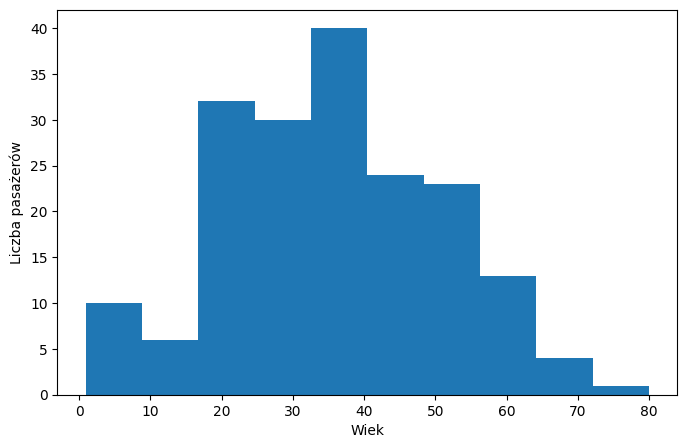

In [ ]:
# wizualizacja rozkładu cechy "Age" bez wartości liczbowej

# Analiza samego średniego wieku nie daje pełnego obrazu sytuacji, dlatego przygotowany został histogram przedstawiający rozkład cechy Age.

dane_wiek = dane.dropna()
plt.figure(figsize=(8, 5))
plt.hist(dane_wiek["Age"])
plt.xlabel("Wiek")
plt.ylabel("Liczba pasażerów")
plt.show()


In [ ]:
# Na podstawie wyników możemy zaobserwować że najliczniejszą grupą na statku byuli pasażerowie w przedziale wiekowym od około 20 do 40 lat.
# występuje róznież widoczność dla najmłodszego przedziału, wskazującego na udział małych dzieci czyli rodzin w wycieczce.

In [ ]:
# wskaźnik przeżycia według klasy "Pclass" biletu pasażera

# Analizujemy czy klasa biletów miała istotny wpływ na przeżycie na statku.
# Wykorzystujemy funkcję groupby(), grupując dane względem kolumny Pclass. Obliczona średnia dla kolumny Survived.

print(dane.groupby("Pclass")["Survived"].mean())

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [ ]:
# Klasa 1: Najwyższy wskaźnik przeżycia wynoszący około 63%, pasażerowie tej klasy mieli najlepszy dostęp do pokładów spacerowych i szalup
# Klasa 2: Umiarkowany wskaźnik przeżycia na poziomie 47%.
# Klasa 3: Najniższe szanse na przeżycie, jedynie 24%. Pasażerowie tej klasy podróżowali na najniższych pokładach, co znacznie utrudniało ewakuację.

In [ ]:
# wskaźnik przeżycia według klasy "Embarked" portu zaokrętowania pasażera

# Analizujemy czy port zaokrętowania pasażera miał wpływ na wskaźnik przeżycia.

print(dane.groupby("Embarked")["Survived"].mean())

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [ ]:
# Zauważalnie najwyższy wskaźnik przeżycia występuje dla portu Cherbourg około 55%. Dla Queenstown i Southampton są znajcznie niższe około 39% i 34%


Po wstępnej analizie zidentyfikowano główne przeszkody i zaplanowano następujące kroki:
- Dane w kolumnie ,,Cabin" zostaną usunięte ze względu na bardzo dużą liczbę brakujących wartości.
- Kolumny ,,PassengerID", ,,Name" oraz ,,Ticket" zostaną usunięte z uwagi na ich unikalność i brak bezpośredniej wartości predykcyjnej.
- Brakujące dane w kolumnie ,,Age" zostaną zastąpione średnią wartością wieku.
- Brakujące dane w kolumnie ,,Embarked" powodują że 2 wartości danych zostaną usunięte z bazy z względu na minimalny wpływ na model.
- Dane w kolumnie ,,Sex" zostaną przekształcone na dane binarne; male -> 0, female -> 1.
- Dane kategorialne ,,Pclass" i ,,Embarked" zostaną przekształcone na kolumny binarne za pomocą One-Hot Encoding. Wymagane przez modele liniowe, aby poprawnie przetwarzać zmienne.

In [ ]:
kolumny_do_usuniecia = ["PassengerId", "Name", "Ticket", "Cabin"]
dane.drop(kolumny_do_usuniecia, axis=1, inplace=True)
# usuwamy dane z względu na sporą liczbę brakujących wartości oraz nie istotne statystycznie

In [ ]:
dane["Age"].fillna(dane["Age"].mean(), inplace=True)
# zastępujemy brakujące dane średnią wieku

/tmp/ipython-input-3740517711.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dane["Age"].fillna(dane["Age"].mean(), inplace=True)


In [ ]:
dane.dropna(subset=["Embarked"], inplace=True)
# usunięcie wierszy z brakiem wartości w kolumnie "Embarked"

In [ ]:
if "mele" in dane["Sex"].unique():
  dane["Sex"] = dane["Sex"].replace("mele", "male")
# z względu na literówke

dane["Sex_encoded"] = dane["Sex"].map({"male": 0, "female": 1})
dane.drop("Sex", axis=1, inplace=True)
# przekształcenie za pomocą funkcji mapującej na wartości binarne

In [ ]:
dane = pd.get_dummies(dane, columns=["Pclass", "Embarked"], drop_first=True)
# Kodyfikacja zmiennych kategorycznych za pomoca One-Hot Encoding

In [ ]:
dane.head()

# Sprawdzamy dane w fianalnej formie, za pomocą funkcji dane.head()

,Survived,Age,SibSp,Parch,Fare,Sex_encoded,Pclass_2,Pclass_3,Embarked_Q,Embarked_S
0,0,22.0,1,0,7.2500,0,False,True,False,True
1,1,38.0,1,0,71.2833,1,False,False,False,False
2,1,26.0,0,0,7.9250,1,False,True,False,True
3,1,35.0,1,0,53.1000,1,False,False,False,True
4,0,35.0,0,0,8.0500,0,False,True,False,True


In [ ]:
dane.info()

# Sprawdzamy integralność danych po preprocesingu za pomocą metody dane.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Survived     889 non-null    int64  
 1   Age          889 non-null    float64
 2   SibSp        889 non-null    int64  
 3   Parch        889 non-null    int64  
 4   Fare         889 non-null    float64
 5   Sex_encoded  889 non-null    int64  
 6   Pclass_2     889 non-null    bool   
 7   Pclass_3     889 non-null    bool   
 8   Embarked_Q   889 non-null    bool   
 9   Embarked_S   889 non-null    bool   
dtypes: bool(4), float64(2), int64(4)
memory usage: 52.1 KB


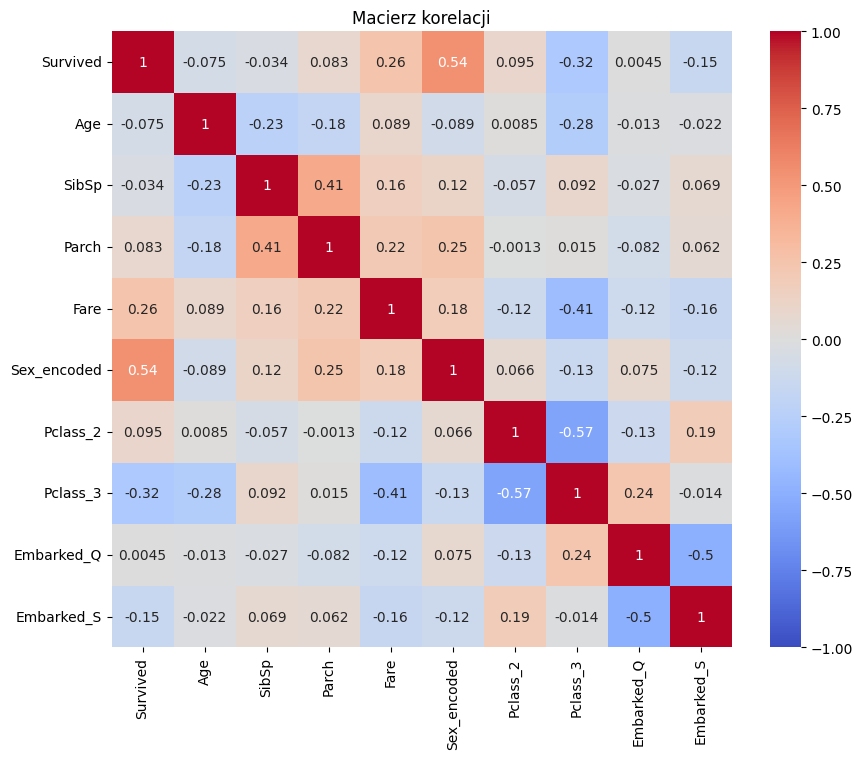

In [ ]:
# Funkcja correlation_matrix = dane.corr() oblicza współczynnik korelacji Pearsona dla każdej pary kolumn. Wynik to tabela, w której  wartości bliskie 1 oznaczają silna zależność dodatnią, a bliskie -1 silną zależnośc ujmeną, a 0 brak zwiazku liniowego
correlation_matrix = dane.corr()

# plt.figure ustala rozmiar wykresu
plt.figure(figsize=(10, 8))
# sns.heatmap tworzy tzw. "mape ciepła" annot=True - nanosi konkretne wartości licznowe na kolory; cmap = "coolwarm" nadaje kolory (niebiski dla ujemnych, czerwony dla dodatnich) co ułatwia szybką interpretację ; vmin=-1 , vmax=1 ustala sztywną skalę, aby kolor zawsze odpowiadał tym samym wartościa
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
# dodajemy tytuł i wyświetlamy obraz
plt.title("Macierz korelacji")
plt.show()


W celu weryfikacji siły predykcyjnej cech po preprocessingu, obliczono macierz korelacji względem zmiennej docelowej "Surviced". Wizualizacja pomaga nam potwierdzić, które zmienne będą miały największą siłę predykcyjną.

Macierz korelacji potwierdza że zmienne "Sex_encoded" są najistotniejszą cechą predykcyjną do wskaźnika przeżycia, korelacja na poziomie 0.54.

**Podział danych**

Dane dzielimy na cechy i etykiety.

Cechy (X) - zmienne które poslużą nam do przewidywania

Etykiety (Y) - zmienna docelowa, którą chcemy przewidzieć

In [ ]:
# X - cechy
X = dane.drop("Survived", axis=1)
# Y - etykiety
Y = dane["Survived"]

Podział na zbiór treningowy i testowy.

Dane zostaną podzielone za pomocą funkcji sklearn.model_selection.train_test_split().

 Dane dzielimy w przedziale 80% dane treningowe i 20% dane testowe.

 Kluczowy w procesie walidacji modelu. Zapewnia, że model jest trenowany wyłącznie na jednym podzbiorze danych, a jego wydajność jest oceniania na niewidocznym dla niego zbiorze testowym.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Rozmiar zbioru treningowego:", X_train.shape)
print("Rozmiar zbioru testowego:", X_test.shape)

Rozmiar zbioru treningowego: (711, 9)
Rozmiar zbioru testowego: (178, 9)


# Wybór Modeli i Trenowanie

In [ ]:
# Regresja Logistyczna

from sklearn.linear_model import LogisticRegression
model_lr = LogisticRegression(max_iter=200)

# trenowanie modelu regresji liniowej
model_lr.fit(X_train, Y_train)

LogisticRegression(max_iter=200)

In [ ]:
# Klasyfikator Lasu Losowego

from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)

# trenowanie modelu
model_rf.fit(X_train, Y_train)

RandomForestClassifier(max_depth=7, random_state=42)

Model 1 "Logistic Regression" został wybrany jako model bazowy. Jest to prosty, szybki w trenowaniu i prezentuję wysoką interpretowalność wyników.

Model 2 "Random Forest Classifier" jest to model nieliniowy i zespołowy, składający się z wielu niezależnych drzew decyzyjnych. Jest skutecznym, odpornym na przetrenowanie modelem oraz potrafi wychwytać złożone interakcje między cechami.

# Ewaluacja modeli i porównanie

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def metryki(y_true, y_pred, y_proba, model_name):
  # obliczenie metryk
  return {
      "Model": model_name,
      "Accuracy": accuracy_score(y_true, y_pred),
      "Precision": precision_score(y_true, y_pred),
      "Recall": recall_score(y_true, y_pred),
      "F1-Score": f1_score(y_true, y_pred),
      "ROC AUC": roc_auc_score(y_true, y_proba)
  }

  # predykcja na zbiorze testowym
Y_pred_lr = model_lr.predict(X_test)
Y_proba_lr = model_lr.predict_proba(X_test)[:, 1]
Y_pred_rf = model_rf.predict(X_test)
Y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

wyniki_lr = metryki(Y_test, Y_pred_lr, Y_proba_lr, "Regresja Logistyczna")
wyniki_rf = metryki(Y_test, Y_pred_rf, Y_proba_rf, "Las Losowy")

wyniki_df = pd.DataFrame([wyniki_lr, wyniki_rf])

In [ ]:
print(wyniki_df.to_markdown(index=False, floatfmt=".4f"))

| Model                |   Accuracy |   Precision |   Recall |   F1-Score |   ROC AUC |
|:---------------------|-----------:|------------:|---------:|-----------:|----------:|
| Regresja Logistyczna |     0.7978 |      0.7324 |   0.7536 |     0.7429 |    0.8517 |
| Las Losowy           |     0.7978 |      0.7619 |   0.6957 |     0.7273 |    0.8506 |


**Prezentacja i wizualizacja whyników**



--- Tabela Porównawcza Wyników Modeli na Zbiorze Testowym ---
| Model                |   Accuracy |   Precision |   Recall |   F1-Score |   ROC AUC |
|:---------------------|-----------:|------------:|---------:|-----------:|----------:|
| Regresja Logistyczna |     0.7978 |      0.7324 |   0.7536 |     0.7429 |    0.8517 |
| Las Losowy           |     0.7978 |      0.7619 |   0.6957 |     0.7273 |    0.8506 |


/tmp/ipython-input-1518912029.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='ROC AUC', data=wyniki_df, palette='viridis')


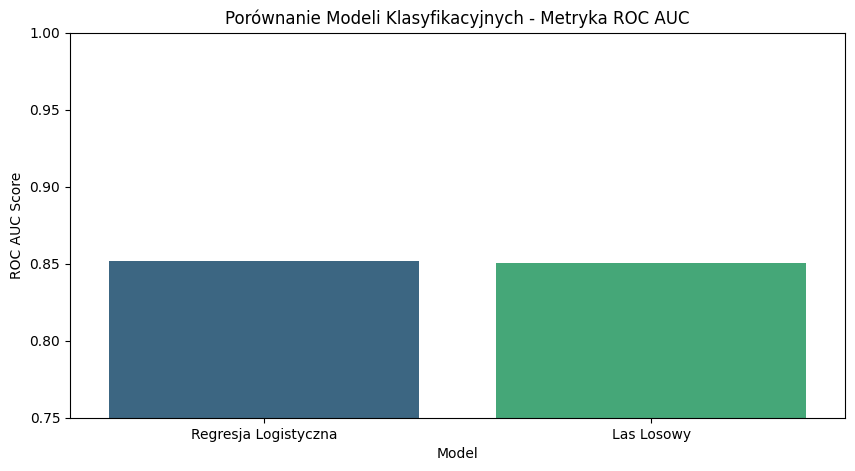

In [ ]:
# Sortowanie wyników według najważniejszej metryki: ROC AUC (malejąco)
wyniki_df = wyniki_df.sort_values(by='ROC AUC', ascending=False).reset_index(drop=True)

print("--- Tabela Porównawcza Wyników Modeli na Zbiorze Testowym ---")
# Użycie to_markdown() dla czytelnej prezentacji w notatniku
print(wyniki_df.to_markdown(index=False, floatfmt=".4f"))

# Wizualizacja ROC AUC
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='ROC AUC', data=wyniki_df, palette='viridis')
plt.title('Porównanie Modeli Klasyfikacyjnych - Metryka ROC AUC')
plt.ylabel('ROC AUC Score')
plt.ylim(0.75, 1.0) # Ułatwia wizualne porównanie wysokich wyników
plt.show()

# Wyniki i interpretacja #

Wydajność obu modeli jest wyrównana (oba mają co samo "Accuracy" = 0.7978), jednak model regresji liniowej "Regression Logistic" okazał się optymalny, osiągając najwyższą wartość ROC AUC (0.817).

Ze względu na minimalną przewagę w kluczowej metryce i jednocześnie większą prostotę i interpretowalność, Regresja Logiczna jest wybierana jako lepszy model predykcyjny.



Fakt, że prosty model liniowy "Regression Logistic" uzyskał minimalnie lepsze wyniki niż złożony model zespołowy "Random Forest", jest istony. Sugeruje to, że dominujące zależności w danych są linowe i wystarczające do efektywnej predykcji.

Model "Random Forest" charakteryzował się wyższą precyzją (0.7619), ale "Regression Logistic" osiągnął lepszą czułość (0.7536) i lepszy F1-Score (0.7429), co oznacza, że zapewniła lepszą równowagę między błędami fałszywie pozytywnymi i negatywnymi.

# Analiza ważności cech #

Trzy najważniejsze cechy, które miały największy wpływ na predykcję przeżycia:
|             |      0 |
|:------------|-------:|
| Sex_encoded | 0.3665 |
| Fare        | 0.2259 |
| Age         | 0.1462 |


/tmp/ipython-input-1768961880.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.head(3).values, y=feature_importances.head(3).index, palette='plasma')


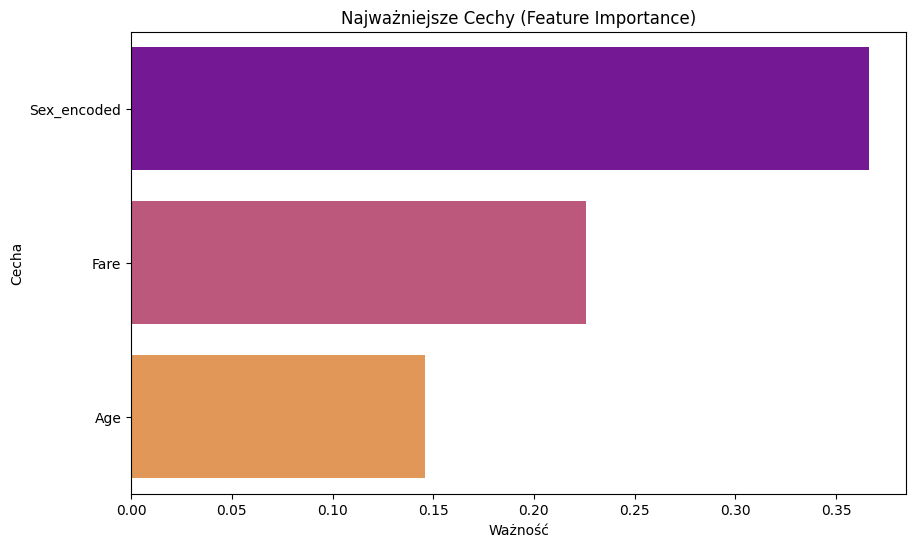

In [ ]:
# Używamy modelu "Random Forest", ponieważ udostępnia Feature Importance.

feature_importances = pd.Series(model_rf.feature_importances_, index=X_train.columns)
feature_importances = feature_importances.sort_values(ascending=False)

print("Trzy najważniejsze cechy, które miały największy wpływ na predykcję przeżycia:")
print(feature_importances.head(3).to_markdown(floatfmt=".4f"))

# Wizualizacja ważności cech
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.head(3).values, y=feature_importances.head(3).index, palette='plasma')
plt.title("Najważniejsze Cechy (Feature Importance)")
plt.xlabel("Ważność")
plt.ylabel("Cecha")
plt.show()

Mimo że wybrano "Regression Logistic", to analiza ważności cech z modelu "Random Forest" dostarcza kluczowego wglądu w hierarchie znaczenia cech i służy potwierdzeniu wyników z analizy danych.

Wizualizacja jasno pokazuje, które zmienne miały największy wpływ na decyzję modelu o przeżyciu pasażera.

Zdecydowanie najważniejszym predykatorem przeżyć jest jest Płeć, z wagą wynoszącą 36.65%. Bycie mężczyzną drastycznie zmniejsza szansę na przeżycie, co jest zgodne z historycznym hasłem "Kobiety i dzieci pierwsze".
Rola opłaty za bilet "Fare" znalazła się na drugim miejscu z wynikiem 22.59%. Wartość ta jest silnie powiązana z klasą biletu "Pclass", ponieważ droższe bilety oznaczały pierwszą klasę, a tym samym lepszy dostęp do szalup ratunkowych.
Wiek "Age" jest trzecim co do ważności czynnikiem 14.62%. Potwierdza to, że młodsze osoby miały większe szanse na przeżycie.